In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Standardize the data
X_std = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

# Calculate the covariance matrix
cov_matrix = np.cov(X_std, rowvar=False)

# Calculate eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvalues and corresponding eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

In [2]:
X.shape

(150, 4)

In [3]:
sorted_indices

array([0, 1, 2, 3])

In [11]:
eigenvectors

array([[ 0.52106591, -0.37741762, -0.71956635,  0.26128628],
       [-0.26934744, -0.92329566,  0.24438178, -0.12350962],
       [ 0.5804131 , -0.02449161,  0.14212637, -0.80144925],
       [ 0.56485654, -0.06694199,  0.63427274,  0.52359713]])

In [12]:
eigenvalues

array([2.93808505, 0.9201649 , 0.14774182, 0.02085386])

In [6]:
# Visualize the explained variance
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

In [7]:
explained_variance_ratio

array([0.72962445, 0.22850762, 0.03668922, 0.00517871])

In [8]:
cumulative_explained_variance

array([0.72962445, 0.95813207, 0.99482129, 1.        ])

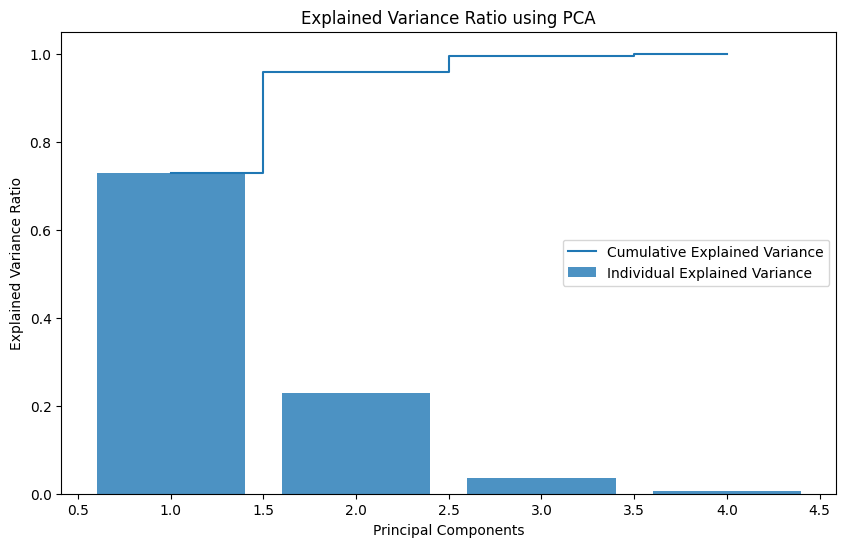

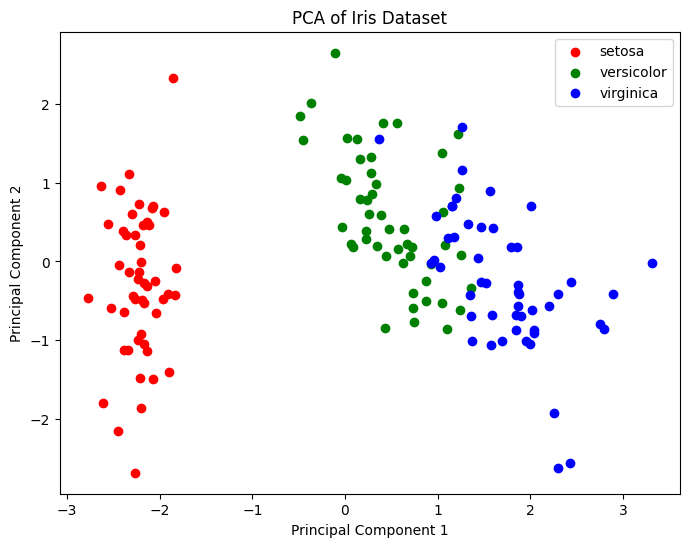

In [9]:

# Plotting the explained variance
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.8, align='center',
        label='Individual Explained Variance')
plt.step(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, where='mid',
         label='Cumulative Explained Variance')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio using PCA')
plt.legend(loc='best')
plt.show()

# Choose the number of components
num_components = 2
selected_eigenvectors = eigenvectors[:, :num_components]

# Project the data onto the selected principal components
X_pca = X_std.dot(selected_eigenvectors)

# Visualize the reduced-dimensional data
plt.figure(figsize=(8, 6))
for i, c in zip(range(3), ['red', 'green', 'blue']):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], c=c, label=iris.target_names[i])

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset')
plt.legend()
plt.show()


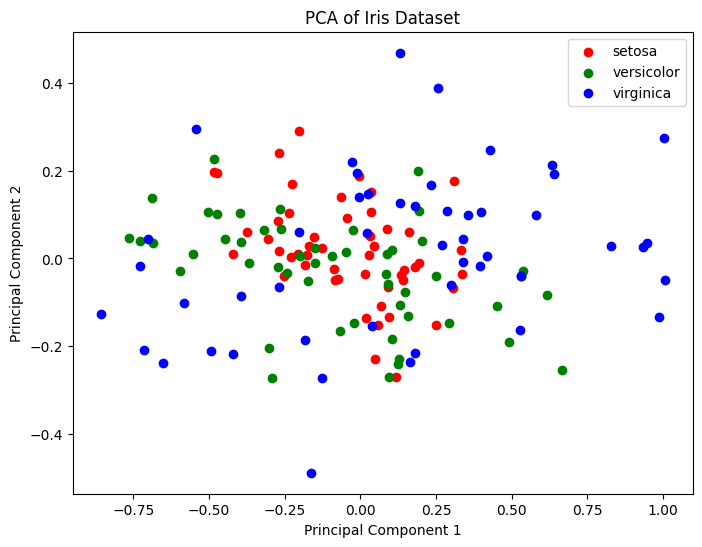

In [10]:
# Choose the number of components
selected_eigenvectors = eigenvectors[:, 2:]

# Project the data onto the selected principal components
X_pca = X_std.dot(selected_eigenvectors)

# Visualize the reduced-dimensional data
plt.figure(figsize=(8, 6))
for i, c in zip(range(3), ['red', 'green', 'blue']):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], c=c, label=iris.target_names[i])

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset')
plt.legend()
plt.show()